# Bank Transaction Analysis Pandas Project

**Goal:** Learn how to work with daily bank transaction files, preserve historical records, update the master dataset, merge account information, calculate balances, and extract useful business insights.

### Project workflow
`Daily CSV files → Pandas → Combine/Update → Clean → Merge Accounts → Calculate Balances → Insights → 10 Graphs`



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
BASE = Path("data")
DAILY = BASE / "daily"

In [4]:
BASE

WindowsPath('data')

In [5]:
DAILY

WindowsPath('data/daily')

## 1. Load all daily transaction files

Every day the bank receives a new CSV. We read all available daily files and combine them into one historical dataset.


In [6]:
daily_files = sorted(DAILY.glob("*.csv"))
len(daily_files), daily_files


(91,
 [WindowsPath('data/daily/2026-01-01.csv'),
  WindowsPath('data/daily/2026-01-02.csv'),
  WindowsPath('data/daily/2026-01-03.csv'),
  WindowsPath('data/daily/2026-01-04.csv'),
  WindowsPath('data/daily/2026-01-05.csv'),
  WindowsPath('data/daily/2026-01-06.csv'),
  WindowsPath('data/daily/2026-01-07.csv'),
  WindowsPath('data/daily/2026-01-08.csv'),
  WindowsPath('data/daily/2026-01-09.csv'),
  WindowsPath('data/daily/2026-01-10.csv'),
  WindowsPath('data/daily/2026-01-11.csv'),
  WindowsPath('data/daily/2026-01-12.csv'),
  WindowsPath('data/daily/2026-01-13.csv'),
  WindowsPath('data/daily/2026-01-14.csv'),
  WindowsPath('data/daily/2026-01-15.csv'),
  WindowsPath('data/daily/2026-01-16.csv'),
  WindowsPath('data/daily/2026-01-17.csv'),
  WindowsPath('data/daily/2026-01-18.csv'),
  WindowsPath('data/daily/2026-01-19.csv'),
  WindowsPath('data/daily/2026-01-20.csv'),
  WindowsPath('data/daily/2026-01-21.csv'),
  WindowsPath('data/daily/2026-01-22.csv'),
  WindowsPath('data/daily/2

In [7]:
daily_frames = [pd.read_csv(file) for file in daily_files if "new_day" not in file.name]


# daily_frames1 = []

# for file in daily_files:
#     if "new_day" not in file.name:
#         daily_frames1.append(pd.read_csv(file))

daily_frames

[         Date Account_ID Transaction_Type  Amount     Branch
 0  2026-01-01       A008          Deposit   37000     Lahore
 1  2026-01-01       A009       Withdrawal   11500  Islamabad
 2  2026-01-01       A001       Withdrawal   37000    Karachi
 3  2026-01-01       A008       Withdrawal   26500     Lahore
 4  2026-01-01       A002          Deposit   42500     Lahore
 5  2026-01-01       A004       Withdrawal   39500    Karachi
 6  2026-01-01       A007       Withdrawal   28000    Karachi,
          Date Account_ID Transaction_Type  Amount     Branch
 0  2026-01-02       A005       Withdrawal   12500     Lahore
 1  2026-01-02       A009       Withdrawal    5000  Islamabad
 2  2026-01-02       A003       Withdrawal   32000  Islamabad
 3  2026-01-02       A008       Withdrawal   19000     Lahore
 4  2026-01-02       A005       Withdrawal   44500     Lahore
 5  2026-01-02       A008          Deposit   19500     Lahore
 6  2026-01-02       A005          Deposit    8000     Lahore
 7  202

In [9]:
transactions = pd.concat(daily_frames, ignore_index=True)
transactions


,Date,Account_ID,Transaction_Type,Amount,Branch
0,2026-01-01,A008,Deposit,37000,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore
...,...,...,...,...,...
864,2026-03-31,A005,Withdrawal,44000,Lahore
865,2026-03-31,A005,Withdrawal,27000,Lahore
866,2026-03-31,A005,Deposit,38500,Lahore
867,2026-03-31,A002,Deposit,40000,Lahore


In [10]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              869 non-null    object
 1   Account_ID        869 non-null    object
 2   Transaction_Type  869 non-null    object
 3   Amount            869 non-null    int64 
 4   Branch            869 non-null    object
dtypes: int64(1), object(4)
memory usage: 34.1+ KB


In [11]:
transactions["Date"] = pd.to_datetime(transactions["Date"])
transactions

,Date,Account_ID,Transaction_Type,Amount,Branch
0,2026-01-01,A008,Deposit,37000,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore
...,...,...,...,...,...
864,2026-03-31,A005,Withdrawal,44000,Lahore
865,2026-03-31,A005,Withdrawal,27000,Lahore
866,2026-03-31,A005,Deposit,38500,Lahore
867,2026-03-31,A002,Deposit,40000,Lahore


In [12]:
transactions.dtypes

Date                datetime64[ns]
Account_ID                  object
Transaction_Type            object
Amount                       int64
Branch                      object
dtype: object

In [13]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              869 non-null    datetime64[ns]
 1   Account_ID        869 non-null    object        
 2   Transaction_Type  869 non-null    object        
 3   Amount            869 non-null    int64         
 4   Branch            869 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 34.1+ KB


In [14]:
transactions.to_csv('all transaction.csv',index=False)

## 2. Important: daily update without losing old records

The master `transactions.csv` contains the previous history. When a new day arrives, we append the new day's records instead of replacing the old data.


In [15]:
old_data = pd.read_csv("all transaction.csv")
print(old_data.info())
old_data["Date"] = pd.to_datetime(old_data["Date"])
print(old_data)
print(old_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              869 non-null    object
 1   Account_ID        869 non-null    object
 2   Transaction_Type  869 non-null    object
 3   Amount            869 non-null    int64 
 4   Branch            869 non-null    object
dtypes: int64(1), object(4)
memory usage: 34.1+ KB
None
          Date Account_ID Transaction_Type  Amount     Branch
0   2026-01-01       A008          Deposit   37000     Lahore
1   2026-01-01       A009       Withdrawal   11500  Islamabad
2   2026-01-01       A001       Withdrawal   37000    Karachi
3   2026-01-01       A008       Withdrawal   26500     Lahore
4   2026-01-01       A002          Deposit   42500     Lahore
..         ...        ...              ...     ...        ...
864 2026-03-31       A005       Withdrawal   44000     Lahore
865 2026-03-31       A

In [16]:
old_data.duplicated().sum()

np.int64(1)

In [17]:
old_data.drop_duplicates(inplace=True)

In [18]:
old_data.duplicated().sum()

np.int64(0)

In [19]:
old_data.count()

Date                868
Account_ID          868
Transaction_Type    868
Amount              868
Branch              868
dtype: int64

In [20]:
BASE

WindowsPath('data')

In [21]:
DAILY

WindowsPath('data/daily')

In [22]:
new_day = pd.read_csv(DAILY / "2026-04-01_new_day.csv")
print(new_day.info())
new_day["Date"] = pd.to_datetime(new_day["Date"])
new_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              9 non-null      object
 1   Account_ID        9 non-null      object
 2   Transaction_Type  9 non-null      object
 3   Amount            9 non-null      int64 
 4   Branch            9 non-null      object
dtypes: int64(1), object(4)
memory usage: 492.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              9 non-null      datetime64[ns]
 1   Account_ID        9 non-null      object        
 2   Transaction_Type  9 non-null      object        
 3   Amount            9 non-null      int64         
 4   Branch            9 non-null      object        
dtypes: datetime64[ns](1), int64(1), obj

In [23]:
new_day

,Date,Account_ID,Transaction_Type,Amount,Branch
0,2026-04-01,A005,Deposit,13000,Lahore
1,2026-04-01,A008,Deposit,59000,Lahore
2,2026-04-01,A010,Withdrawal,48500,Karachi
3,2026-04-01,A009,Withdrawal,8000,Islamabad
4,2026-04-01,A003,Deposit,23500,Islamabad
5,2026-04-01,A005,Withdrawal,49000,Lahore
6,2026-04-01,A002,Withdrawal,22500,Lahore
7,2026-04-01,A003,Withdrawal,22000,Islamabad
8,2026-04-01,A003,Withdrawal,44500,Islamabad


In [24]:
old_data

,Date,Account_ID,Transaction_Type,Amount,Branch
0,2026-01-01,A008,Deposit,37000,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore
...,...,...,...,...,...
864,2026-03-31,A005,Withdrawal,44000,Lahore
865,2026-03-31,A005,Withdrawal,27000,Lahore
866,2026-03-31,A005,Deposit,38500,Lahore
867,2026-03-31,A002,Deposit,40000,Lahore


In [26]:
updated_data = pd.concat([old_data, new_day], ignore_index=True)
updated_data

,Date,Account_ID,Transaction_Type,Amount,Branch
0,2026-01-01,A008,Deposit,37000,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore
...,...,...,...,...,...
872,2026-04-01,A003,Deposit,23500,Islamabad
873,2026-04-01,A005,Withdrawal,49000,Lahore
874,2026-04-01,A002,Withdrawal,22500,Lahore
875,2026-04-01,A003,Withdrawal,22000,Islamabad


In [27]:
updated_data.duplicated().sum()

np.int64(0)

In [28]:
BASE

WindowsPath('data')

In [29]:
updated_data.to_csv(BASE / "transactions_updated.csv", index=False)


In [30]:
print("Old rows:", len(old_data))
print("New rows:", len(new_day))
print("Updated rows:", len(updated_data))


Old rows: 868
New rows: 9
Updated rows: 877


### Optional reusable daily update function

Run this function whenever a new daily CSV arrives. It keeps the previous history and adds only new transactions.


In [ ]:
def update_master_file(new_file, master_file="data/transactions.csv"):
    master = pd.read_csv(master_file)
    new = pd.read_csv(new_file)

    master["Date"] = pd.to_datetime(master["Date"])
    new["Date"] = pd.to_datetime(new["Date"])

    updated = pd.concat([master, new], ignore_index=True)
    updated = updated.drop_duplicates()

    updated.to_csv(master_file, index=False)
    return updated

# Example:
# updated = update_master_file("data/daily/2026-04-01_new_day.csv")
# updated.tail()


In [31]:
BASE

WindowsPath('data')

## 3. Load account information and merge it with transactions


In [32]:
accounts = pd.read_csv(BASE / "accounts.csv")
accounts


,Account_ID,Customer_Name,Account_Type,Branch
0,A001,Ali Khan,Saving,Karachi
1,A002,Sara Ahmed,Current,Lahore
2,A003,Ahmed Raza,Saving,Islamabad
3,A004,Ayesha Noor,Saving,Karachi
4,A005,Usman Ali,Current,Lahore
5,A006,Hina Malik,Saving,Islamabad
6,A007,Bilal Shah,Saving,Karachi
7,A008,Fatima Noor,Current,Lahore
8,A009,Hamza Tariq,Saving,Islamabad
9,A010,Zainab Ali,Saving,Karachi


In [34]:
updated_data.columns

Index(['Date', 'Account_ID', 'Transaction_Type', 'Amount', 'Branch'], dtype='object')

In [36]:
bank = pd.merge(
    updated_data,
    accounts,
    on="Account_ID",
    how="left",
    suffixes=("", "_Account")
)
bank


,Date,Account_ID,Transaction_Type,Amount,Branch,Customer_Name,Account_Type,Branch_Account
0,2026-01-01,A008,Deposit,37000,Lahore,Fatima Noor,Current,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad,Hamza Tariq,Saving,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi,Ali Khan,Saving,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore,Fatima Noor,Current,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore,Sara Ahmed,Current,Lahore
...,...,...,...,...,...,...,...,...
872,2026-04-01,A003,Deposit,23500,Islamabad,Ahmed Raza,Saving,Islamabad
873,2026-04-01,A005,Withdrawal,49000,Lahore,Usman Ali,Current,Lahore
874,2026-04-01,A002,Withdrawal,22500,Lahore,Sara Ahmed,Current,Lahore
875,2026-04-01,A003,Withdrawal,22000,Islamabad,Ahmed Raza,Saving,Islamabad


## 4. Basic data checks


In [37]:
print(bank.shape)

(877, 8)


In [38]:
print(bank.isnull().sum())

Date                0
Account_ID          0
Transaction_Type    0
Amount              0
Branch              0
Customer_Name       0
Account_Type        0
Branch_Account      0
dtype: int64


In [39]:
bank.duplicated().sum()

np.int64(0)

In [41]:
bank["Transaction_Type"]

0         Deposit
1      Withdrawal
2      Withdrawal
3      Withdrawal
4         Deposit
          ...    
872       Deposit
873    Withdrawal
874    Withdrawal
875    Withdrawal
876    Withdrawal
Name: Transaction_Type, Length: 877, dtype: object

In [40]:
print(bank["Transaction_Type"].value_counts())

Transaction_Type
Deposit       468
Withdrawal    409
Name: count, dtype: int64


In [42]:
print(bank["Branch"].value_counts())


Branch
Karachi      338
Lahore       279
Islamabad    260
Name: count, dtype: int64


## 5. Core banking metrics

We calculate total deposits, total withdrawals, net movement, and transaction count.


In [43]:
bank

,Date,Account_ID,Transaction_Type,Amount,Branch,Customer_Name,Account_Type,Branch_Account
0,2026-01-01,A008,Deposit,37000,Lahore,Fatima Noor,Current,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad,Hamza Tariq,Saving,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi,Ali Khan,Saving,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore,Fatima Noor,Current,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore,Sara Ahmed,Current,Lahore
...,...,...,...,...,...,...,...,...
872,2026-04-01,A003,Deposit,23500,Islamabad,Ahmed Raza,Saving,Islamabad
873,2026-04-01,A005,Withdrawal,49000,Lahore,Usman Ali,Current,Lahore
874,2026-04-01,A002,Withdrawal,22500,Lahore,Sara Ahmed,Current,Lahore
875,2026-04-01,A003,Withdrawal,22000,Islamabad,Ahmed Raza,Saving,Islamabad


In [44]:
bank.loc[bank["Transaction_Type"] == "Deposit"]

,Date,Account_ID,Transaction_Type,Amount,Branch,Customer_Name,Account_Type,Branch_Account
0,2026-01-01,A008,Deposit,37000,Lahore,Fatima Noor,Current,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore,Sara Ahmed,Current,Lahore
12,2026-01-02,A008,Deposit,19500,Lahore,Fatima Noor,Current,Lahore
13,2026-01-02,A005,Deposit,8000,Lahore,Usman Ali,Current,Lahore
15,2026-01-02,A004,Deposit,77500,Karachi,Ayesha Noor,Saving,Karachi
...,...,...,...,...,...,...,...,...
866,2026-03-31,A002,Deposit,40000,Lahore,Sara Ahmed,Current,Lahore
867,2026-03-31,A005,Deposit,64500,Lahore,Usman Ali,Current,Lahore
868,2026-04-01,A005,Deposit,13000,Lahore,Usman Ali,Current,Lahore
869,2026-04-01,A008,Deposit,59000,Lahore,Fatima Noor,Current,Lahore


In [45]:
bank.loc[bank["Transaction_Type"] == "Deposit", "Amount"]

0      37000
4      42500
12     19500
13      8000
15     77500
       ...  
866    40000
867    64500
868    13000
869    59000
872    23500
Name: Amount, Length: 468, dtype: int64

In [46]:
total_deposits = bank.loc[bank["Transaction_Type"] == "Deposit", "Amount"].sum()
total_deposits

np.int64(19082500)

In [47]:
total_withdrawals = bank.loc[bank["Transaction_Type"] == "Withdrawal", "Amount"].sum()
net_movement = total_deposits - total_withdrawals
print(total_withdrawals)
print(net_movement)

10944500
8138000


In [48]:
transaction_count = len(bank)
transaction_count

877

In [49]:


summary = pd.DataFrame({
    "Metric": ["Total Deposits", "Total Withdrawals", "Net Movement", "Transactions"],
    "Value": [total_deposits, total_withdrawals, net_movement, transaction_count]
})
summary


,Metric,Value
0,Total Deposits,19082500
1,Total Withdrawals,10944500
2,Net Movement,8138000
3,Transactions,877


## 6. Current balance by account

For a simple learning model:

`Balance = Total Deposits − Total Withdrawals`


In [50]:
deposit_by_account = bank[bank["Transaction_Type"] == "Deposit"].groupby("Account_ID")["Amount"].sum()
withdrawal_by_account = bank[bank["Transaction_Type"] == "Withdrawal"].groupby("Account_ID")["Amount"].sum()

In [51]:
deposit_by_account

Account_ID
A001    2076500
A002    1904500
A003    1714000
A004    1662000
A005    2278000
A006    1907500
A007    1619500
A008    1666000
A009    1656500
A010    2598000
Name: Amount, dtype: int64

In [52]:
withdrawal_by_account

Account_ID
A001     829000
A002    1116000
A003    1266500
A004    1096000
A005    1121500
A006    1537500
A007     843500
A008    1124500
A009     874500
A010    1135500
Name: Amount, dtype: int64

In [54]:
balance = pd.DataFrame({
    "Total_Deposits": deposit_by_account,
    "Total_Withdrawals": withdrawal_by_account
})
balance

,Total_Deposits,Total_Withdrawals
Account_ID,,
A001,2076500,829000
A002,1904500,1116000
A003,1714000,1266500
A004,1662000,1096000
A005,2278000,1121500
A006,1907500,1537500
A007,1619500,843500
A008,1666000,1124500
A009,1656500,874500


In [55]:

balance["Current_Balance"] = balance["Total_Deposits"] - balance["Total_Withdrawals"]

balance

,Total_Deposits,Total_Withdrawals,Current_Balance
Account_ID,,,
A001,2076500,829000,1247500
A002,1904500,1116000,788500
A003,1714000,1266500,447500
A004,1662000,1096000,566000
A005,2278000,1121500,1156500
A006,1907500,1537500,370000
A007,1619500,843500,776000
A008,1666000,1124500,541500
A009,1656500,874500,782000


In [56]:
accounts

,Account_ID,Customer_Name,Account_Type,Branch
0,A001,Ali Khan,Saving,Karachi
1,A002,Sara Ahmed,Current,Lahore
2,A003,Ahmed Raza,Saving,Islamabad
3,A004,Ayesha Noor,Saving,Karachi
4,A005,Usman Ali,Current,Lahore
5,A006,Hina Malik,Saving,Islamabad
6,A007,Bilal Shah,Saving,Karachi
7,A008,Fatima Noor,Current,Lahore
8,A009,Hamza Tariq,Saving,Islamabad
9,A010,Zainab Ali,Saving,Karachi


In [57]:
balance = balance.merge(accounts, on="Account_ID", how="left",suffixes=("","_Account"))
balance

,Account_ID,Total_Deposits,Total_Withdrawals,Current_Balance,Customer_Name,Account_Type,Branch
0,A001,2076500,829000,1247500,Ali Khan,Saving,Karachi
1,A002,1904500,1116000,788500,Sara Ahmed,Current,Lahore
2,A003,1714000,1266500,447500,Ahmed Raza,Saving,Islamabad
3,A004,1662000,1096000,566000,Ayesha Noor,Saving,Karachi
4,A005,2278000,1121500,1156500,Usman Ali,Current,Lahore
5,A006,1907500,1537500,370000,Hina Malik,Saving,Islamabad
6,A007,1619500,843500,776000,Bilal Shah,Saving,Karachi
7,A008,1666000,1124500,541500,Fatima Noor,Current,Lahore
8,A009,1656500,874500,782000,Hamza Tariq,Saving,Islamabad
9,A010,2598000,1135500,1462500,Zainab Ali,Saving,Karachi


# 7. Ten insightful graphs

The graphs answer practical questions about bank activity rather than being included just for decoration.


In [58]:
bank

,Date,Account_ID,Transaction_Type,Amount,Branch,Customer_Name,Account_Type,Branch_Account
0,2026-01-01,A008,Deposit,37000,Lahore,Fatima Noor,Current,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad,Hamza Tariq,Saving,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi,Ali Khan,Saving,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore,Fatima Noor,Current,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore,Sara Ahmed,Current,Lahore
...,...,...,...,...,...,...,...,...
872,2026-04-01,A003,Deposit,23500,Islamabad,Ahmed Raza,Saving,Islamabad
873,2026-04-01,A005,Withdrawal,49000,Lahore,Usman Ali,Current,Lahore
874,2026-04-01,A002,Withdrawal,22500,Lahore,Sara Ahmed,Current,Lahore
875,2026-04-01,A003,Withdrawal,22000,Islamabad,Ahmed Raza,Saving,Islamabad


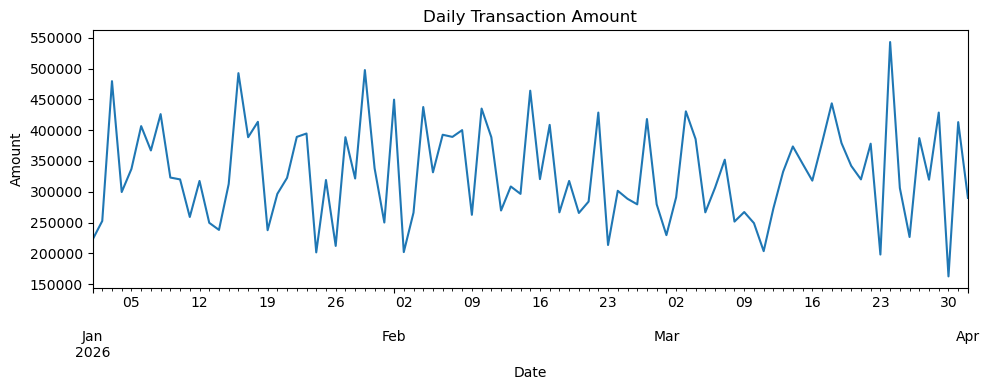

In [62]:
# Graph 1 Daily transaction amount
daily_amount = bank.groupby("Date")["Amount"].sum()
daily_amount.plot(kind="line", figsize=(10,4), title="Daily Transaction Amount")
plt.ylabel("Amount")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


In [63]:
daily_type = bank.pivot_table(index="Date", columns="Transaction_Type", 
                              values="Amount", aggfunc="sum")
daily_type

Transaction_Type,Deposit,Withdrawal
Date,,
2026-01-01,79500,142500
2026-01-02,105000,147500
2026-01-03,364000,115500
2026-01-04,222500,77000
2026-01-05,262000,75000
...,...,...
2026-03-28,184000,135500
2026-03-29,263000,165500
2026-03-30,51000,111500


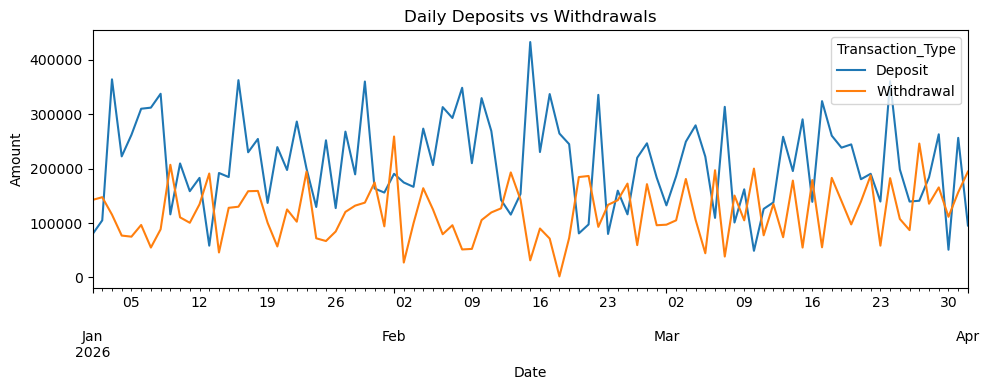

In [64]:
# Graph 2 Daily deposits vs withdrawals


daily_type.plot(kind="line", figsize=(10,4), title="Daily Deposits vs Withdrawals")
plt.ylabel("Amount")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


Branch
Karachi      11860000
Lahore        9210500
Islamabad     8956500
Name: Amount, dtype: int64


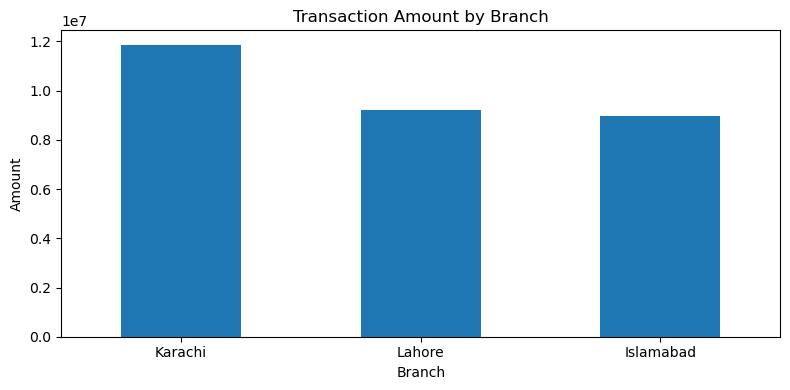

In [65]:
# Graph 3 Branch transaction amount
branch_amount = bank.groupby("Branch")["Amount"].sum().sort_values(ascending=False)
print(branch_amount)

branch_amount.plot(kind="bar", figsize=(8,4), title="Transaction Amount by Branch")
plt.ylabel("Amount")
plt.xlabel("Branch")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


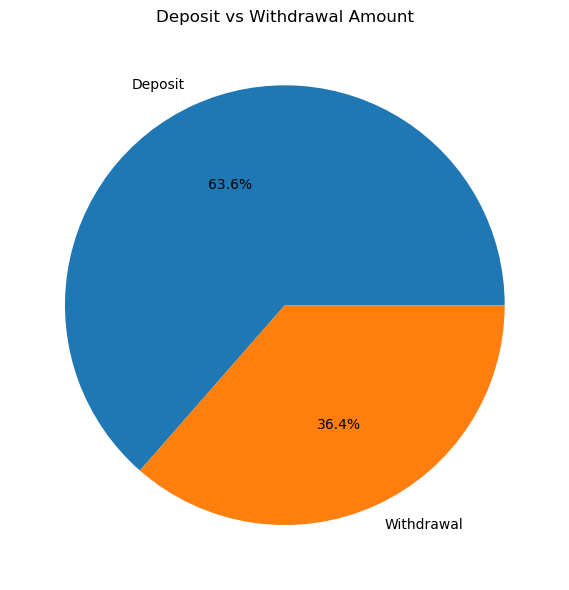

In [66]:
# Graph 4 Deposit vs withdrawal composition
type_amount = bank.groupby("Transaction_Type")["Amount"].sum()
type_amount.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6), title="Deposit vs Withdrawal Amount")
plt.ylabel("")
plt.tight_layout()
plt.show()


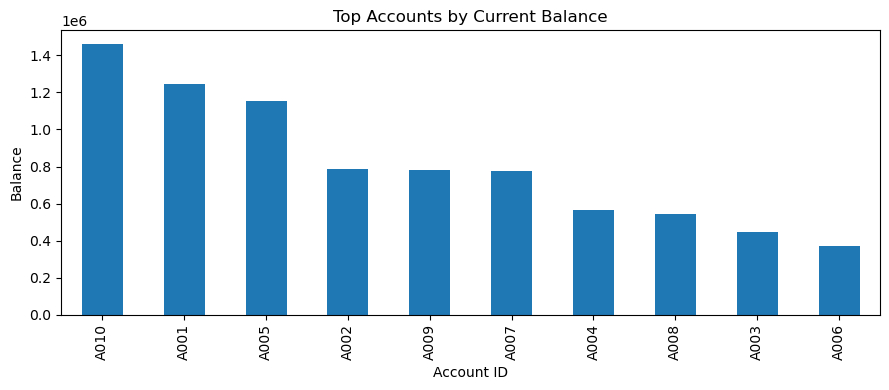

In [67]:
# Graph 5 Top accounts by current balance
top_balance = balance.sort_values("Current_Balance", ascending=False).head(10)
top_balance.set_index("Account_ID")["Current_Balance"].plot(
    kind="bar", figsize=(9,4), title="Top Accounts by Current Balance"
)
plt.ylabel("Balance")
plt.xlabel("Account ID")
plt.tight_layout()
plt.show()


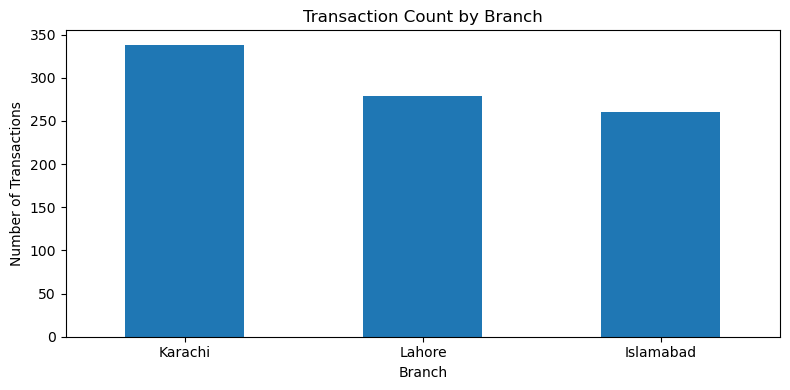

In [71]:
# Graph 6 Number of transactions by branch
branch_count = bank["Branch"].value_counts()
branch_count.plot(kind="bar", figsize=(8,4), title="Transaction Count by Branch")
plt.ylabel("Number of Transactions")
plt.xlabel("Branch")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


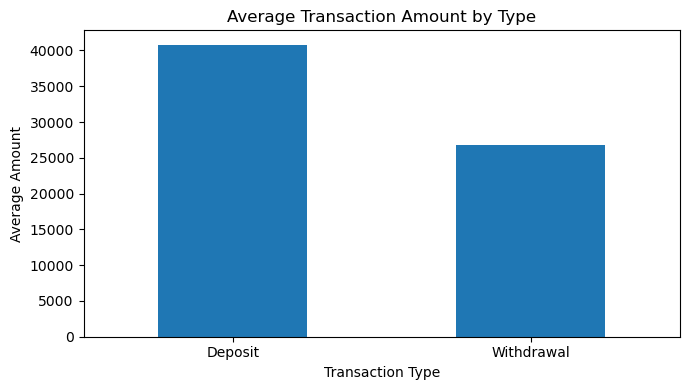

In [72]:
# Graph 7 Average transaction amount by type
avg_type = bank.groupby("Transaction_Type")["Amount"].mean()
avg_type.plot(kind="bar", figsize=(7,4), title="Average Transaction Amount by Type")
plt.ylabel("Average Amount")
plt.xlabel("Transaction Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Graph 8 Monthly net movement


In [73]:
bank

,Date,Account_ID,Transaction_Type,Amount,Branch,Customer_Name,Account_Type,Branch_Account
0,2026-01-01,A008,Deposit,37000,Lahore,Fatima Noor,Current,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad,Hamza Tariq,Saving,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi,Ali Khan,Saving,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore,Fatima Noor,Current,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore,Sara Ahmed,Current,Lahore
...,...,...,...,...,...,...,...,...
872,2026-04-01,A003,Deposit,23500,Islamabad,Ahmed Raza,Saving,Islamabad
873,2026-04-01,A005,Withdrawal,49000,Lahore,Usman Ali,Current,Lahore
874,2026-04-01,A002,Withdrawal,22500,Lahore,Sara Ahmed,Current,Lahore
875,2026-04-01,A003,Withdrawal,22000,Islamabad,Ahmed Raza,Saving,Islamabad


In [74]:
monthly = bank.assign(Month=bank["Date"].dt.to_period("M"))
monthly

,Date,Account_ID,Transaction_Type,Amount,Branch,Customer_Name,Account_Type,Branch_Account,Month
0,2026-01-01,A008,Deposit,37000,Lahore,Fatima Noor,Current,Lahore,2026-01
1,2026-01-01,A009,Withdrawal,11500,Islamabad,Hamza Tariq,Saving,Islamabad,2026-01
2,2026-01-01,A001,Withdrawal,37000,Karachi,Ali Khan,Saving,Karachi,2026-01
3,2026-01-01,A008,Withdrawal,26500,Lahore,Fatima Noor,Current,Lahore,2026-01
4,2026-01-01,A002,Deposit,42500,Lahore,Sara Ahmed,Current,Lahore,2026-01
...,...,...,...,...,...,...,...,...,...
872,2026-04-01,A003,Deposit,23500,Islamabad,Ahmed Raza,Saving,Islamabad,2026-04
873,2026-04-01,A005,Withdrawal,49000,Lahore,Usman Ali,Current,Lahore,2026-04
874,2026-04-01,A002,Withdrawal,22500,Lahore,Sara Ahmed,Current,Lahore,2026-04
875,2026-04-01,A003,Withdrawal,22000,Islamabad,Ahmed Raza,Saving,Islamabad,2026-04


In [75]:
monthly_net = monthly.pivot_table(index="Month", columns="Transaction_Type", values="Amount", aggfunc="sum")
monthly_net

Transaction_Type,Deposit,Withdrawal
Month,,
2026-01,6648000,3624000
2026-02,6215000,3149000
2026-03,6124000,3977000
2026-04,95500,194500


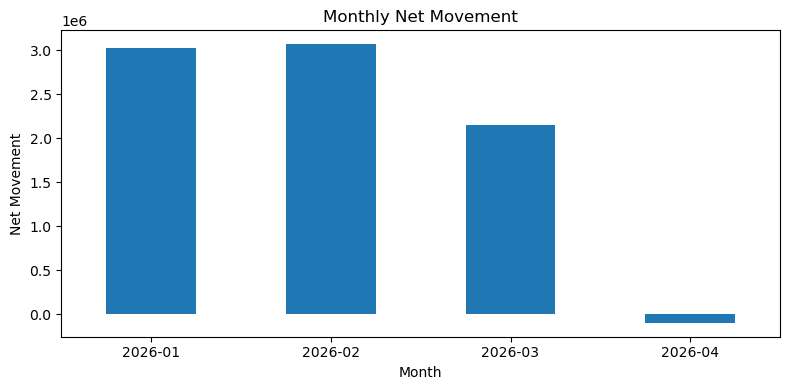

In [76]:
monthly_net["Net_Movement"] = monthly_net.get("Deposit", 0) - monthly_net.get("Withdrawal", 0)
monthly_net["Net_Movement"].plot(kind="bar", figsize=(8,4), title="Monthly Net Movement")
plt.ylabel("Net Movement")
plt.xlabel("Month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


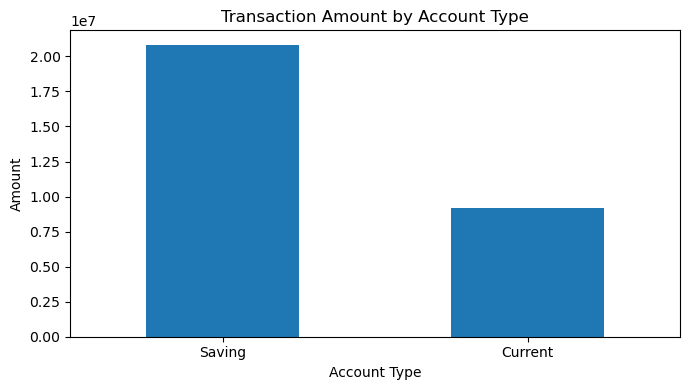

In [77]:
# Graph 9 Account type activity
account_type_amount = bank.groupby("Account_Type")["Amount"].sum().sort_values(ascending=False)
account_type_amount.plot(kind="bar", figsize=(7,4), title="Transaction Amount by Account Type")
plt.ylabel("Amount")
plt.xlabel("Account Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


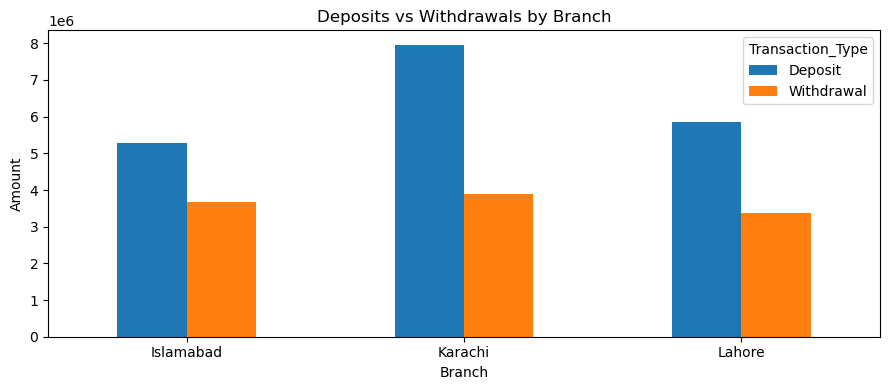

In [78]:
# Graph 10 Deposits and withdrawals by branch
branch_type = bank.pivot_table(index="Branch", columns="Transaction_Type",
                               values="Amount", aggfunc="sum", fill_value=0)
branch_type.plot(kind="bar", figsize=(9,4), title="Deposits vs Withdrawals by Branch")
plt.ylabel("Amount")
plt.xlabel("Branch")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 8. Insightful summary

Use the tables and graphs above to answer:

1. Which branch handles the highest transaction amount?
2. Are deposits higher than withdrawals overall?
3. Which account has the highest current balance?
4. Which branch has the highest transaction count?
5. Are average deposits larger than average withdrawals?
6. Which month has the strongest positive/negative net movement?
7. Which account type contributes more transaction value?
8. Which branch has the largest difference between deposits and withdrawals?
9. Which days show unusually high transaction activity?
10. Does the bank appear to have positive overall net movement?

The important point is to explain **what the numbers mean for the bank**, not just print them.


In [79]:
total_deposits

np.int64(19082500)

In [80]:
branch_amount

Branch
Karachi      11860000
Lahore        9210500
Islamabad     8956500
Name: Amount, dtype: int64

In [81]:
balance

,Account_ID,Total_Deposits,Total_Withdrawals,Current_Balance,Customer_Name,Account_Type,Branch
0,A001,2076500,829000,1247500,Ali Khan,Saving,Karachi
1,A002,1904500,1116000,788500,Sara Ahmed,Current,Lahore
2,A003,1714000,1266500,447500,Ahmed Raza,Saving,Islamabad
3,A004,1662000,1096000,566000,Ayesha Noor,Saving,Karachi
4,A005,2278000,1121500,1156500,Usman Ali,Current,Lahore
5,A006,1907500,1537500,370000,Hina Malik,Saving,Islamabad
6,A007,1619500,843500,776000,Bilal Shah,Saving,Karachi
7,A008,1666000,1124500,541500,Fatima Noor,Current,Lahore
8,A009,1656500,874500,782000,Hamza Tariq,Saving,Islamabad
9,A010,2598000,1135500,1462500,Zainab Ali,Saving,Karachi


In [82]:
# Automatic final summary
print("TOTAL DEPOSITS:", f"{total_deposits:,.0f}")
print("TOTAL WITHDRAWALS:", f"{total_withdrawals:,.0f}")
print("NET MOVEMENT:", f"{net_movement:,.0f}")

print("\nHighest transaction branch:")
print(branch_amount.idxmax(), f"({branch_amount.max():,.0f})")

print("\nHighest balance account:")
r = balance.loc[balance["Current_Balance"].idxmax()]
print(r["Account_ID"], r["Customer_Name"], f"({r['Current_Balance']:,.0f})")

print("\nHighest transaction count branch:")
print(branch_count.idxmax(), f"({branch_count.max()} transactions)")


TOTAL DEPOSITS: 19,082,500
TOTAL WITHDRAWALS: 10,944,500
NET MOVEMENT: 8,138,000

Highest transaction branch:
Karachi (11,860,000)

Highest balance account:
A010 Zainab Ali (1,462,500)

Highest transaction count branch:
Karachi (338 transactions)
